# `clarity` — Sequência de tokens (CNN/BiGRU) × algoritmos de embedding, com CV e métricas completas

**Escopo enxuto:** mantém a arquitetura do notebook anterior (texto como sequência → TextCNN / BiGRU) e troca só o que alimenta a camada `Embedding`.

| Embedding | O que muda vs. o W2V anterior |
|---|---|
| `w2v` | Referência (mesmos hiperparâmetros), agora com números/e-mails/URLs normalizados |
| `fasttext` | Subwords: `solictação` ≈ `solicitação`; palavras nunca vistas no treino ganham vetor em vez de `<unk>` |
| `nilc` (opcional) | Pré-treinado em córpus grande de PT-BR (repositório NILC) |

**Avaliação**
- Baseline TF-IDF + LogReg como régua, mesmo split do notebook anterior (hold-out 20%, `random_state=42` → comparável ao 0,4482).
- **CV 5-fold estratificado** nos 80% de desenvolvimento. Embeddings, vocabulário, pesos de classe e early stopping são refeitos dentro de cada fold.
- Métricas: accuracy, balanced accuracy, precision/recall/F1 macro, F1 weighted (média ± desvio).
- Significância vs baseline: *corrected resampled t-test* (Nadeau & Bengio, 2003).
- Hold-out tocado uma única vez, no final.


In [14]:
# !pip install -U gensim scikit-learn pandas openpyxl torch
import os, re, time, random, warnings
from collections import Counter
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, classification_report, confusion_matrix)
from gensim.models import Word2Vec, FastText, KeyedVectors

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ---------------- Configuração ----------------
ARQ, TEXTCOL, LABELCOL = "train.xlsx", "resp_text", "clarity"
N_FOLDS  = 5
FRAC_DEV = 1.0            # 0.3 para iterar rápido

EMBEDDINGS = ["w2v", "fasttext"]   # + "nilc" se baixar o pré-treinado
ARQS       = ["cnn"]               # + "bigru" (~2-3x mais lento que a CNN)
FREEZE     = [False, True]               # [False, True] testa embedding congelado vs fine-tune

EMB_DIM, EMB_WINDOW, EMB_EPOCHS, EMB_MINCOUNT = 300, 5, 10, 2   # iguais ao notebook anterior
WORKERS   = os.cpu_count()
NILC_PATH = "skip_s300.txt"   # http://nilc.icmc.usp.br/nilc/index.php/repositorio-de-word-embeddings-do-nilc

NN_EPOCHS, NN_LR, NN_PATIENCE, NN_BS = 15, 1e-3, 3, 64
VERBOSE = True


## 1. Dados, split idêntico ao anterior e folds

In [15]:
df = pd.read_excel(ARQ, na_values=["na"], decimal=",")
df = df.dropna(subset=[TEXTCOL, LABELCOL]).reset_index(drop=True)
TXT = df[TEXTCOL].astype(str).values
Y   = df[LABELCOL].astype(str).values
print(df.shape); print(pd.Series(Y).value_counts(normalize=True).round(3))

idx_dev, idx_te = train_test_split(np.arange(len(df)), test_size=0.20,
                                   stratify=Y, random_state=SEED)
if FRAC_DEV < 1.0:
    idx_dev, _ = train_test_split(idx_dev, train_size=FRAC_DEV,
                                  stratify=Y[idx_dev], random_state=SEED)
print(f"dev={len(idx_dev):,}  hold-out={len(idx_te):,}")

FOLDS = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
             .split(idx_dev, Y[idx_dev]))
LE = LabelEncoder().fit(Y); N_CLASSES = len(LE.classes_)


(20092, 2)
c5      0.343
c234    0.341
c1      0.316
Name: proportion, dtype: float64
dev=16,073  hold-out=4,019


## 2. Normalização + tokenização
Números de protocolo, e-mails e URLs viram tokens únicos. No notebook anterior eles eram os vizinhos mais próximos de `informação`. Sem stopwords, stemming ou lematização (slides 40–42).

In [16]:
RE_URL  = re.compile(r"https?://\S+|www\.\S+")
RE_MAIL = re.compile(r"\S+@\S+\.\S+")
RE_NUM  = re.compile(r"\d+(?:[.,/\-]\d+)*")

def normaliza(t):
    t = t.lower()
    t = RE_URL.sub(" urltok ", t)
    t = RE_MAIL.sub(" emailtok ", t)
    return RE_NUM.sub(" numtok ", t)

ANALYZER = TfidfVectorizer(preprocessor=normaliza).build_analyzer()
TOK = [ANALYZER(t) for t in TXT]
def toks(idx): return [TOK[i] for i in idx]

lens = np.array([len(TOK[i]) for i in idx_dev])
MAX_LEN = int(min(512, np.percentile(lens, 90)))
print(f"tokens/doc p50={np.percentile(lens,50):.0f}  p90={np.percentile(lens,90):.0f}  →  MAX_LEN={MAX_LEN}")


tokens/doc p50=93  p90=281  →  MAX_LEN=281


## 3. Motor de avaliação

In [17]:
METRICAS = {
    "accuracy":        accuracy_score,
    "balanced_acc":    balanced_accuracy_score,
    "precision_macro": lambda y, p: precision_score(y, p, average="macro", zero_division=0),
    "recall_macro":    lambda y, p: recall_score(y, p, average="macro", zero_division=0),
    "f1_macro":        lambda y, p: f1_score(y, p, average="macro"),
    "f1_weighted":     lambda y, p: f1_score(y, p, average="weighted"),
}
def calc_metricas(y, p): return {k: f(y, p) for k, f in METRICAS.items()}

CV, OOF, FAMILIA, FAMILIA_FN, TEMPO, HOLDOUT = {}, {}, {}, {}, {}, {}
REF = "BASELINE TF-IDF + LogReg"

def roda_cv(familia, fn):
    # fn(idx_treino, idx_teste) -> {nome_modelo: y_pred}
    FAMILIA_FN[familia] = fn; t0 = time.time()
    for f, (a, b) in enumerate(FOLDS):
        tr, te = idx_dev[a], idx_dev[b]
        print(f"[{familia}] fold {f+1}/{N_FOLDS}")
        for nome, p in fn(tr, te).items():
            FAMILIA[nome] = familia
            CV.setdefault(nome, [None] * N_FOLDS)[f] = calc_metricas(Y[te], p)
            OOF.setdefault(nome, np.empty(len(idx_dev), dtype=object))[b] = p
        print(f"  ({time.time()-t0:.0f}s acumulados)")
    TEMPO[familia] = time.time() - t0
    display(resumo(familia))

def t_corrigido(nome, ref=REF, metrica="f1_macro"):
    # Nadeau & Bengio (2003): corrige a variância pela sobreposição dos treinos entre folds
    if ref not in CV or nome == ref: return np.nan, np.nan
    d = np.array([m[metrica] for m in CV[nome]]) - np.array([m[metrica] for m in CV[ref]])
    k, n_te, n_tr = len(d), len(FOLDS[0][1]), len(FOLDS[0][0])
    var = d.var(ddof=1)
    if var == 0: return d.mean(), np.nan
    t = d.mean() / np.sqrt((1 / k + n_te / n_tr) * var)
    return d.mean(), 2 * stats.t.sf(abs(t), df=k - 1)

def resumo(familia=None):
    rows = []
    for nome, folds in CV.items():
        if familia and FAMILIA[nome] != familia: continue
        m = pd.DataFrame(folds); r = {"modelo": nome}
        for c in METRICAS:
            r[c] = m[c].mean(); r[c + "_sd"] = m[c].std(ddof=1)
        r["Δf1_vs_base"], r["p_valor"] = t_corrigido(nome)
        rows.append(r)
    cols = ["modelo", "f1_macro", "f1_macro_sd", "accuracy", "balanced_acc",
            "precision_macro", "recall_macro", "f1_weighted", "Δf1_vs_base", "p_valor"]
    return (pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
            .reset_index(drop=True)[cols].round(4))


## 4. Baseline (idêntico ao anterior)

In [18]:
def fam_baseline(tr, te):
    v = TfidfVectorizer()
    Xa, Xb = v.fit_transform(TXT[tr]), v.transform(TXT[te])
    clf = LogisticRegression(class_weight="balanced", max_iter=2000).fit(Xa, Y[tr])
    return {REF: clf.predict(Xb)}

roda_cv("baseline", fam_baseline)


[baseline] fold 1/5
  (22s acumulados)
[baseline] fold 2/5
  (37s acumulados)
[baseline] fold 3/5
  (56s acumulados)
[baseline] fold 4/5
  (71s acumulados)
[baseline] fold 5/5
  (87s acumulados)


,modelo,f1_macro,f1_macro_sd,accuracy,balanced_acc,precision_macro,recall_macro,f1_weighted,Δf1_vs_base,p_valor
0,BASELINE TF-IDF + LogReg,0.4529,0.0094,0.4554,0.4566,0.4519,0.4566,0.4521,NaN,NaN


## 5. Construção da matriz de embeddings por algoritmo
Índices: `0 = <pad>`, `1 = <unk>`, `2… = palavras`.
- **w2v:** só palavras do treino com `min_count` → o resto vira `<unk>`.
- **fasttext:** palavras do treino **+ qualquer token do fold de teste** recebe vetor via n-gramas de caracteres (usa só o texto, nunca o rótulo).
- **nilc:** vetores congelados de origem externa; cobertura depende da tokenização (slide 47).

In [19]:
KV_NILC = None
if "nilc" in EMBEDDINGS:
    t0 = time.time()
    KV_NILC = KeyedVectors.load_word2vec_format(NILC_PATH, binary=False, unicode_errors="ignore")
    print(f"NILC: vocab={len(KV_NILC):,} dim={KV_NILC.vector_size} ({time.time()-t0:.0f}s)")

def constroi_embedding(nome, tr, te):
    tok_tr = toks(tr)
    if nome == "w2v":
        kv = Word2Vec(tok_tr, vector_size=EMB_DIM, window=EMB_WINDOW, min_count=EMB_MINCOUNT,
                      sg=1, seed=SEED, workers=WORKERS, epochs=EMB_EPOCHS).wv
        palavras = list(kv.index_to_key)
    elif nome == "fasttext":
        kv = FastText(tok_tr, vector_size=EMB_DIM, window=EMB_WINDOW, min_count=EMB_MINCOUNT,
                      sg=1, min_n=3, max_n=6, seed=SEED, workers=WORKERS, epochs=EMB_EPOCHS).wv
        vistos = set(kv.index_to_key)
        extra = sorted({w for t in tok_tr + toks(te) for w in t} - vistos)
        palavras = list(kv.index_to_key) + extra
    elif nome == "nilc":
        kv = KV_NILC
        cont = Counter(w for t in tok_tr + toks(te) for w in t)
        palavras = [w for w, _ in cont.most_common() if w in kv.key_to_index]
    else:
        raise ValueError(nome)
    dim = kv.vector_size
    M = np.zeros((len(palavras) + 2, dim), dtype=np.float32)
    M[1] = np.random.default_rng(SEED).normal(0, 0.1, dim)
    M[2:] = np.vstack([kv[w] for w in palavras])
    stoi = {w: i + 2 for i, w in enumerate(palavras)}
    return stoi, M

def encode(tokens, stoi, max_len=MAX_LEN):
    ids = [stoi.get(t, 1) for t in tokens]
    if len(ids) > max_len:                      # cabeça + cauda
        h = max_len // 2
        ids = ids[:h] + ids[-(max_len - h):]
    return ids + [0] * (max_len - len(ids))


## 6. Modelos de sequência (mesma arquitetura do notebook anterior)
Única mudança: parâmetro `freeze`. Com FastText, congelar preserva a coerência dos vetores gerados por subword para palavras que só aparecem no teste (no fine-tune, as palavras do treino "andam" e as do teste ficam paradas).

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

class TextCNN(nn.Module):
    def __init__(self, emb, n_classes, freeze=False, n_filters=128, kernels=(3, 4, 5), dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(torch.tensor(emb), freeze=freeze, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(emb.shape[1], n_filters, k) for k in kernels])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernels), n_classes)
    def forward(self, x):
        e = self.drop(self.emb(x)).transpose(1, 2)
        h = [F.relu(c(e)).max(dim=2).values for c in self.convs]
        return self.fc(self.drop(torch.cat(h, dim=1)))

class BiGRU(nn.Module):
    def __init__(self, emb, n_classes, freeze=False, hidden=128, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(torch.tensor(emb), freeze=freeze, padding_idx=0)
        self.gru = nn.GRU(emb.shape[1], hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(4 * hidden, n_classes)
    def forward(self, x):
        mask = (x != 0).unsqueeze(-1).float()
        h, _ = self.gru(self.drop(self.emb(x)))
        h_max = (h - (1 - mask) * 1e4).max(dim=1).values
        h_avg = (h * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(self.drop(torch.cat([h_max, h_avg], dim=1)))

ARQ_CLS = {"cnn": TextCNN, "bigru": BiGRU}

@torch.no_grad()
def _prever(model, X, bs=256):
    model.eval(); out = []
    for s in range(0, len(X), bs):
        out.append(model(torch.from_numpy(X[s:s + bs]).to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(out)

def treina_e_prever(arq, M, Xa, ya_lbl, Xb, freeze=False, tag=""):
    # Treina em Xa (com validação interna de 10% p/ early stopping) e prevê Xb. Retorna rótulos originais.
    torch.manual_seed(SEED); np.random.seed(SEED)
    ya = LE.transform(ya_lbl)
    i_fit, i_val = train_test_split(np.arange(len(ya)), test_size=0.10, stratify=ya, random_state=SEED)
    w = len(i_fit) / (N_CLASSES * np.bincount(ya[i_fit], minlength=N_CLASSES))
    lossf = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    dl = DataLoader(TensorDataset(torch.from_numpy(Xa[i_fit]), torch.from_numpy(ya[i_fit])),
                    batch_size=NN_BS, shuffle=True)

    model = ARQ_CLS[arq](M, N_CLASSES, freeze=freeze).to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=NN_LR)
    best_f1, best_state, sem_melhora = -1, None, 0
    for ep in range(1, NN_EPOCHS + 1):
        model.train(); t0 = time.time()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        f1v = f1_score(ya[i_val], _prever(model, Xa[i_val]), average="macro")
        if VERBOSE: print(f"    [{tag}] ep{ep:02d} F1_val={f1v:.4f} ({time.time()-t0:.0f}s)")
        if f1v > best_f1:
            best_f1, sem_melhora = f1v, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            sem_melhora += 1
            if sem_melhora >= NN_PATIENCE: break
    model.load_state_dict(best_state)
    return LE.inverse_transform(_prever(model, Xb))


device: cuda


## 7. CV: embeddings × arquiteturas
Imprime também a **cobertura** do fold de teste (% de tokens que não caíram em `<unk>`) — é a evidência direta do ganho do FastText.

In [21]:
COBERTURA = {}

def fam_seq(tr, te):
    out = {}
    for emb in EMBEDDINGS:
        t0 = time.time()
        stoi, M = constroi_embedding(emb, tr, te)
        Xa = np.array([encode(TOK[i], stoi) for i in tr], dtype=np.int64)
        Xb = np.array([encode(TOK[i], stoi) for i in te], dtype=np.int64)
        cob = (Xb > 1).sum() / max((Xb > 0).sum(), 1)
        COBERTURA.setdefault(emb, []).append(cob)
        print(f"  {emb}: vocab={len(stoi):,}  cobertura teste={cob:.2%}  ({time.time()-t0:.0f}s)")
        for arq in ARQS:
            for fz in FREEZE:
                nome = f"{emb.upper()} {M.shape[1]}d + {arq.upper()} | emb {'congelado' if fz else 'fine-tune'}"
                out[nome] = treina_e_prever(arq, M, Xa, Y[tr], Xb, freeze=fz, tag=nome)
    return out

roda_cv("seq", fam_seq)
print({k: f"{np.mean(v):.2%}" for k, v in COBERTURA.items()})


[seq] fold 1/5
  w2v: vocab=18,626  cobertura teste=98.73%  (25s)
    [W2V 300d + CNN | emb fine-tune] ep01 F1_val=0.3949 (2s)
    [W2V 300d + CNN | emb fine-tune] ep02 F1_val=0.3620 (2s)
    [W2V 300d + CNN | emb fine-tune] ep03 F1_val=0.3439 (2s)
    [W2V 300d + CNN | emb fine-tune] ep04 F1_val=0.4173 (2s)
    [W2V 300d + CNN | emb fine-tune] ep05 F1_val=0.4007 (2s)
    [W2V 300d + CNN | emb fine-tune] ep06 F1_val=0.4225 (2s)
    [W2V 300d + CNN | emb fine-tune] ep07 F1_val=0.3946 (2s)
    [W2V 300d + CNN | emb fine-tune] ep08 F1_val=0.3915 (2s)
    [W2V 300d + CNN | emb fine-tune] ep09 F1_val=0.4038 (2s)
    [W2V 300d + CNN | emb congelado] ep01 F1_val=0.4012 (1s)
    [W2V 300d + CNN | emb congelado] ep02 F1_val=0.3561 (1s)
    [W2V 300d + CNN | emb congelado] ep03 F1_val=0.3392 (1s)
    [W2V 300d + CNN | emb congelado] ep04 F1_val=0.3859 (1s)
  fasttext: vocab=33,580  cobertura teste=100.00%  (63s)
    [FASTTEXT 300d + CNN | emb fine-tune] ep01 F1_val=0.3858 (2s)
    [FASTTEXT 300d

,modelo,f1_macro,f1_macro_sd,accuracy,balanced_acc,precision_macro,recall_macro,f1_weighted,Δf1_vs_base,p_valor
0,W2V 300d + CNN | emb fine-tune,0.4278,0.0208,0.4460,0.4491,0.4383,0.4491,0.4261,-0.0252,0.1905
1,FASTTEXT 300d + CNN | emb fine-tune,0.4215,0.0221,0.4406,0.4442,0.4342,0.4442,0.4197,-0.0315,0.1801
2,FASTTEXT 300d + CNN | emb congelado,0.4179,0.0188,0.4359,0.4404,0.4363,0.4404,0.4160,-0.0350,0.0516
3,W2V 300d + CNN | emb congelado,0.4177,0.0146,0.4356,0.4400,0.4345,0.4400,0.4158,-0.0352,0.0384


{'w2v': '98.68%', 'fasttext': '100.00%'}


## 8. Ranking consolidado (CV)

,modelo,f1_macro,f1_macro_sd,accuracy,balanced_acc,precision_macro,recall_macro,f1_weighted,Δf1_vs_base,p_valor
0,BASELINE TF-IDF + LogReg,0.4529,0.0094,0.4554,0.4566,0.4519,0.4566,0.4521,NaN,NaN
1,W2V 300d + CNN | emb fine-tune,0.4278,0.0208,0.4460,0.4491,0.4383,0.4491,0.4261,-0.0252,0.1905
2,FASTTEXT 300d + CNN | emb fine-tune,0.4215,0.0221,0.4406,0.4442,0.4342,0.4442,0.4197,-0.0315,0.1801
3,FASTTEXT 300d + CNN | emb congelado,0.4179,0.0188,0.4359,0.4404,0.4363,0.4404,0.4160,-0.0350,0.0516
4,W2V 300d + CNN | emb congelado,0.4177,0.0146,0.4356,0.4400,0.4345,0.4400,0.4158,-0.0352,0.0384


Tempo por família (s): {'baseline': 87, 'seq': 655}


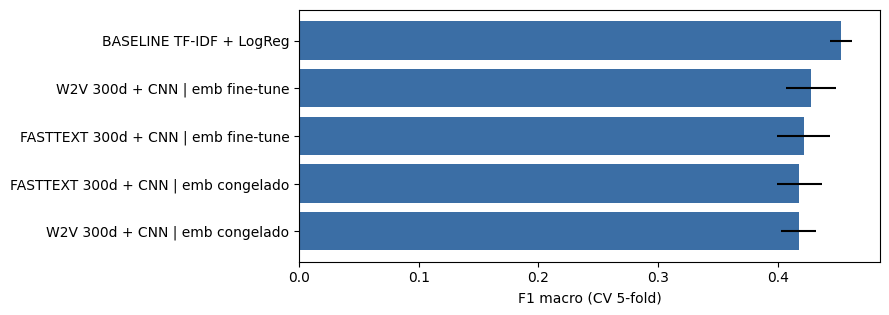

In [22]:
RANK = resumo()
pd.set_option("display.max_colwidth", 70)
display(RANK)
print("Tempo por família (s):", {k: round(v) for k, v in TEMPO.items()})

try:
    import matplotlib.pyplot as plt
    top = RANK.iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 0.45 * len(top) + 1))
    ax.barh(top["modelo"], top["f1_macro"], xerr=top["f1_macro_sd"], color="#3b6ea5")
    ax.set_xlabel(f"F1 macro (CV {N_FOLDS}-fold)"); plt.tight_layout(); plt.show()
except ImportError:
    pass


## 9. Hold-out (tocado uma vez) — todos os modelos, re-treinados no dev completo

In [23]:
PRED_HO = {}
for fam, fn in FAMILIA_FN.items():
    print(f"hold-out: {fam}")
    for nome, p in fn(idx_dev, idx_te).items():
        PRED_HO[nome] = p; HOLDOUT[nome] = calc_metricas(Y[idx_te], p)

HO = pd.DataFrame(HOLDOUT).T.sort_values("f1_macro", ascending=False).round(4)
HO["Δf1_vs_base"] = (HO["f1_macro"] - HO.loc[REF, "f1_macro"]).round(4)
display(HO)

campeao = HO.index[0]
print(f"\nCAMPEÃO: {campeao}\n")
print(classification_report(Y[idx_te], PRED_HO[campeao], digits=4))
classes = list(LE.classes_)
display(pd.DataFrame(confusion_matrix(Y[idx_te], PRED_HO[campeao], labels=classes),
                     index=[f"real {c}" for c in classes], columns=[f"pred {c}" for c in classes]))


hold-out: baseline
hold-out: seq
  w2v: vocab=20,536  cobertura teste=98.84%  (32s)
    [W2V 300d + CNN | emb fine-tune] ep01 F1_val=0.3205 (2s)
    [W2V 300d + CNN | emb fine-tune] ep02 F1_val=0.4035 (2s)
    [W2V 300d + CNN | emb fine-tune] ep03 F1_val=0.4283 (2s)
    [W2V 300d + CNN | emb fine-tune] ep04 F1_val=0.4226 (2s)
    [W2V 300d + CNN | emb fine-tune] ep05 F1_val=0.3929 (2s)
    [W2V 300d + CNN | emb fine-tune] ep06 F1_val=0.4312 (2s)
    [W2V 300d + CNN | emb fine-tune] ep07 F1_val=0.4208 (2s)
    [W2V 300d + CNN | emb fine-tune] ep08 F1_val=0.4109 (2s)
    [W2V 300d + CNN | emb fine-tune] ep09 F1_val=0.4147 (2s)
    [W2V 300d + CNN | emb congelado] ep01 F1_val=0.3136 (1s)
    [W2V 300d + CNN | emb congelado] ep02 F1_val=0.3965 (1s)
    [W2V 300d + CNN | emb congelado] ep03 F1_val=0.4128 (1s)
    [W2V 300d + CNN | emb congelado] ep04 F1_val=0.3817 (1s)
    [W2V 300d + CNN | emb congelado] ep05 F1_val=0.3837 (1s)
    [W2V 300d + CNN | emb congelado] ep06 F1_val=0.4277 (1s)
 

,accuracy,balanced_acc,precision_macro,recall_macro,f1_macro,f1_weighted,Δf1_vs_base
BASELINE TF-IDF + LogReg,0.4504,0.4512,0.4478,0.4512,0.4482,0.4477,0.0000
W2V 300d + CNN | emb fine-tune,0.4474,0.4496,0.4407,0.4496,0.4293,0.4280,-0.0189
W2V 300d + CNN | emb congelado,0.4412,0.4420,0.4319,0.4420,0.4257,0.4248,-0.0225
FASTTEXT 300d + CNN | emb fine-tune,0.4317,0.4351,0.4263,0.4351,0.4235,0.4219,-0.0247
FASTTEXT 300d + CNN | emb congelado,0.4280,0.4320,0.4251,0.4320,0.4142,0.4124,-0.0340



CAMPEÃO: BASELINE TF-IDF + LogReg

              precision    recall  f1-score   support

          c1     0.4552    0.4886    0.4713      1269
        c234     0.4136    0.3508    0.3796      1371
          c5     0.4746    0.5141    0.4936      1379

    accuracy                         0.4504      4019
   macro avg     0.4478    0.4512    0.4482      4019
weighted avg     0.4477    0.4504    0.4477      4019



,pred c1,pred c234,pred c5
real c1,620,337,312
real c234,417,481,473
real c5,325,345,709
